# 1. Imports & Config

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from lifelines.utils import concordance_index

DURATION_COL = 'duration'
EVENT_COL    = 'event'
RANDOM_STATE = 42
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE   = 4096
LR           = 1e-3
MAX_EPOCHS   = 50
PATIENCE     = 10
HIDDEN_DIMS  = [256, 128, 64]
DROPOUT      = 0.3

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print(DEVICE)

cpu


# 2. Load Processed Data

In [13]:
train = pd.read_parquet('/content/data/processed/train.parquet')
val   = pd.read_parquet('/content/data/processed/val.parquet')
test  = pd.read_parquet('/content/data/processed/test.parquet')
print(train.shape, val.shape, test.shape)

(463232, 37) (420801, 37) (1371471, 37)


# 3. FICO Averaging

In [14]:
for df in [train, val, test]:
    df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
    df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

print(train[['fico_score']].describe())

          fico_score
count  463232.000000
mean      698.180978
std        30.768783
min       627.000000
25%       677.000000
50%       692.000000
75%       712.000000
max       847.500000


# 4. Feature Columns

In [15]:
feature_cols = [c for c in train.columns if c not in [DURATION_COL, EVENT_COL]]
numeric_cols = train[feature_cols].select_dtypes(include='number').columns.tolist()
print(len(feature_cols), 'features')
print(feature_cols)

34 features
['loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'term', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'verification_status_Source Verified', 'verification_status_Verified', 'fico_score']


# 5. Scale Features

In [16]:
scaler = StandardScaler()
train[numeric_cols] = scaler.fit_transform(train[numeric_cols])
val[numeric_cols]   = scaler.transform(val[numeric_cols])
test[numeric_cols]  = scaler.transform(test[numeric_cols])

print(train[numeric_cols].describe().loc[['mean', 'std']].round(3))

      loan_amnt  int_rate  installment  grade  sub_grade  emp_length  \
mean        0.0      -0.0         -0.0    0.0       -0.0         0.0   
std         1.0       1.0          1.0    1.0        1.0         1.0   

      annual_inc  dti  delinq_2yrs  open_acc  pub_rec  revol_bal  revol_util  \
mean        -0.0  0.0         -0.0       0.0     -0.0       -0.0        -0.0   
std          1.0  1.0          1.0       1.0      1.0        1.0         1.0   

      total_acc  term  fico_score  
mean       -0.0  -0.0        -0.0  
std         1.0   1.0         1.0  


# 6. DeepSurv Network

In [17]:
class DeepSurv(nn.Module):
    def __init__(self, in_features, hidden_dims, dropout):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


model = DeepSurv(
    in_features=len(feature_cols),
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
).to(DEVICE)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))

DeepSurv(
  (net): Sequential(
    (0): Linear(in_features=34, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
parameters: 51073


# 7. Cox Partial Likelihood Loss

In [18]:
def cox_partial_likelihood_loss(log_risk, durations, events):
    # Inputs must be sorted by descending duration.
    # log_cumsum[i] = log(sum_{j<=i} exp(h_j)), where j=0 has the largest T.
    # For each event i, its risk set denominator is log_cumsum[i].
    log_cumsum = torch.logcumsumexp(log_risk, dim=0)
    neg_log_lik = -torch.mean((log_risk - log_cumsum) * events)
    return neg_log_lik

# 8. DataLoader Setup

In [19]:
X_train_t   = torch.tensor(train[feature_cols].values.astype(np.float32), dtype=torch.float32)
dur_train_t = torch.tensor(train[DURATION_COL].values, dtype=torch.float32)
evt_train_t = torch.tensor(train[EVENT_COL].values,    dtype=torch.float32)

X_val_t     = torch.tensor(val[feature_cols].values.astype(np.float32), dtype=torch.float32)
dur_val_t   = torch.tensor(val[DURATION_COL].values, dtype=torch.float32)
evt_val_t   = torch.tensor(val[EVENT_COL].values,    dtype=torch.float32)

train_ds     = TensorDataset(X_train_t, dur_train_t, evt_train_t)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

print('train batches per epoch:', len(train_loader))

train batches per epoch: 113


# 9. Training Loop

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5
)

train_losses, val_losses, val_cstats = [], [], []
best_c       = -1.0
best_weights = None
patience_count = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for X_b, dur_b, evt_b in train_loader:
        order = torch.argsort(dur_b, descending=True)
        X_b, dur_b, evt_b = X_b[order], dur_b[order], evt_b[order]
        X_b   = X_b.to(DEVICE)
        dur_b = dur_b.to(DEVICE)
        evt_b = evt_b.to(DEVICE)

        optimizer.zero_grad()
        log_risk = model(X_b)
        loss = cox_partial_likelihood_loss(log_risk, dur_b, evt_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
        order_v = torch.argsort(dur_val_t, descending=True)
        log_risk_val_sorted = model(X_val_t[order_v].to(DEVICE))
        vloss = cox_partial_likelihood_loss(
            log_risk_val_sorted,
            dur_val_t[order_v].to(DEVICE),
            evt_val_t[order_v].to(DEVICE),
        ).item()
        log_risk_val_all = model(X_val_t.to(DEVICE)).cpu().numpy()

    c_val = concordance_index(
        val[DURATION_COL].values,
        -log_risk_val_all,
        val[EVENT_COL].values,
    )
    val_losses.append(vloss)
    val_cstats.append(c_val)
    scheduler.step(c_val)

    if c_val > best_c:
        best_c = c_val
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'epoch {epoch:3d}  train_loss={train_losses[-1]:.4f}  val_loss={vloss:.4f}  val_c={c_val:.4f}')

    if patience_count >= PATIENCE:
        print(f'early stop at epoch {epoch}')
        break

model.load_state_dict(best_weights)
print('best val c-stat:', round(best_c, 4))

epoch   1  train_loss=1.2590  val_loss=2.2071  val_c=0.6876
epoch   5  train_loss=1.2525  val_loss=2.2057  val_c=0.6894
epoch  10  train_loss=1.2515  val_loss=2.2051  val_c=0.6905
epoch  15  train_loss=1.2512  val_loss=2.2057  val_c=0.6901
epoch  20  train_loss=1.2503  val_loss=2.2054  val_c=0.6904
epoch  25  train_loss=1.2502  val_loss=2.2056  val_c=0.6907
epoch  30  train_loss=1.2496  val_loss=2.2050  val_c=0.6912
epoch  35  train_loss=1.2491  val_loss=2.2050  val_c=0.6908
epoch  40  train_loss=1.2486  val_loss=2.2050  val_c=0.6905
early stop at epoch 42
best val c-stat: 0.6916


# 10. Training Curve

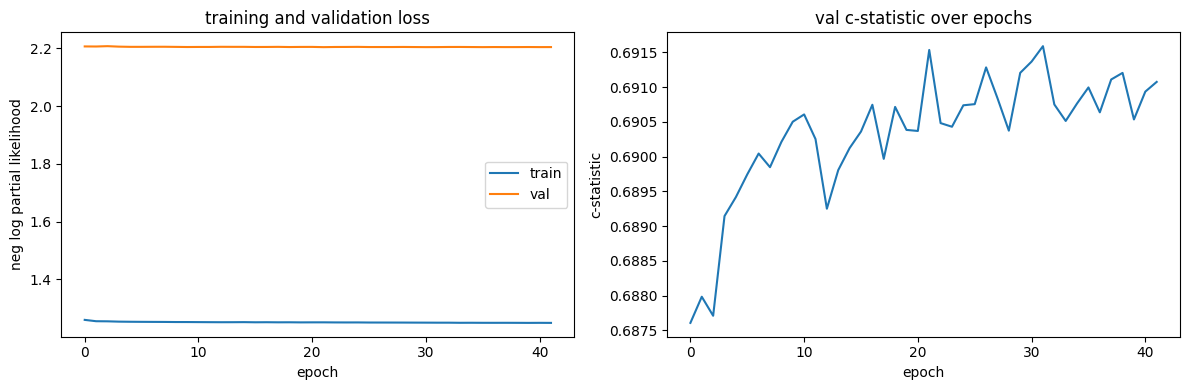

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='train')
ax1.plot(val_losses, label='val')
ax1.set_xlabel('epoch')
ax1.set_ylabel('neg log partial likelihood')
ax1.set_title('training and validation loss')
ax1.legend()

ax2.plot(val_cstats)
ax2.set_xlabel('epoch')
ax2.set_ylabel('c-statistic')
ax2.set_title('val c-statistic over epochs')

plt.tight_layout()
plt.show()

# 11. Breslow Baseline Hazard

In [22]:
INFER_CHUNK = 10_000


def get_risk_scores(model, X_np, chunk_size=INFER_CHUNK, device=DEVICE):
    model.eval()
    n = len(X_np)
    scores = np.empty(n, dtype=np.float32)
    with torch.no_grad():
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            xb = torch.tensor(X_np[start:end], dtype=torch.float32).to(device)
            scores[start:end] = model(xb).cpu().numpy()
    return scores


X_train_np  = train[feature_cols].values.astype(np.float32)
log_h_train = get_risk_scores(model, X_train_np)
exp_h_train = np.exp(log_h_train)

train_durations = train[DURATION_COL].values
train_events    = train[EVENT_COL].values

order       = np.argsort(train_durations)[::-1]
sorted_dur  = train_durations[order]
sorted_evt  = train_events[order]
sorted_exph = exp_h_train[order]

cumsum_exph = np.cumsum(sorted_exph)

unique_event_times = np.unique(sorted_dur[sorted_evt == 1])

dH0 = {}
for t_j in unique_event_times:
    mask_tj  = (sorted_dur == t_j) & (sorted_evt == 1)
    d_j      = mask_tj.sum()
    last_idx = np.searchsorted(-sorted_dur, -t_j, side='right') - 1
    dH0[t_j] = d_j / cumsum_exph[last_idx]

event_times_sorted = np.sort(unique_event_times)
increments         = np.array([dH0[t] for t in event_times_sorted], dtype=np.float64)
H0_cumulative      = np.cumsum(increments)

print('unique event times:', len(event_times_sorted))
print('H_0 at t=12:', H0_cumulative[event_times_sorted <= 12][-1].round(6))
print('H_0 at t=24:', H0_cumulative[event_times_sorted <= 24][-1].round(6))
print('H_0 at t=36:', H0_cumulative[event_times_sorted <= 36][-1].round(6))

unique event times: 66
H_0 at t=12: 0.061248
H_0 at t=24: 0.161551
H_0 at t=36: 0.254728


# 12. Survival Probability Prediction

In [23]:
def lookup_H0(t):
    idx = np.searchsorted(event_times_sorted, t, side='right') - 1
    if idx < 0:
        return 0.0
    return float(H0_cumulative[idx])


def predict_survival_at_horizons(df, horizons=(12, 24, 36)):
    X_np  = df[feature_cols].values.astype(np.float32)
    log_h = get_risk_scores(model, X_np)
    exp_h = np.exp(log_h)
    result = {}
    for t in horizons:
        H0_t = lookup_H0(t)
        result[t] = np.exp(-H0_t * exp_h).astype(np.float32)
    return result


def predict_survival_matrix(df, times=None):
    if times is None:
        times = event_times_sorted
    X_np    = df[feature_cols].values.astype(np.float32)
    log_h   = get_risk_scores(model, X_np)
    exp_h   = np.exp(log_h)
    H0_vals = np.array([lookup_H0(t) for t in times], dtype=np.float64)
    return np.exp(-np.outer(exp_h, H0_vals)).astype(np.float32)


print('val survival at t=12 (first 3):', predict_survival_at_horizons(val.head(3))[12])

val survival at t=12 (first 3): [0.9554968  0.9236096  0.97019637]


# 13. C-Statistic

In [24]:
def compute_cstat(df, label):
    X_np  = df[feature_cols].values.astype(np.float32)
    log_h = get_risk_scores(model, X_np)
    c = concordance_index(
        df[DURATION_COL].values,
        -log_h,
        df[EVENT_COL].values,
    )
    print(label, 'c-statistic:', round(c, 4))
    return c


compute_cstat(val,  'val')
compute_cstat(test, 'test')

val c-statistic: 0.6916
test c-statistic: 0.7015


np.float64(0.7015197564764719)

# 14. Brier Score

In [25]:
def brier_score_at_t(surv_t, durations, events, t):
    died_by_t = ((durations <= t) & (events == 1)).astype(float)
    return np.mean((surv_t - (1 - died_by_t)) ** 2)


def report_brier(df, label):
    surv = predict_survival_at_horizons(df, horizons=[12, 24, 36])
    T = df[DURATION_COL].values
    E = df[EVENT_COL].values
    for t in [12, 24, 36]:
        bs = brier_score_at_t(surv[t], T, E, t)
        print(f'{label} brier score at t={t}: {bs:.4f}')


report_brier(val,  'val')
report_brier(test, 'test')

val brier score at t=12: 0.0549
val brier score at t=24: 0.1083
val brier score at t=36: 0.1341
test brier score at t=12: 0.0438
test brier score at t=24: 0.0711
test brier score at t=36: 0.0875


# 15. Calibration Curves

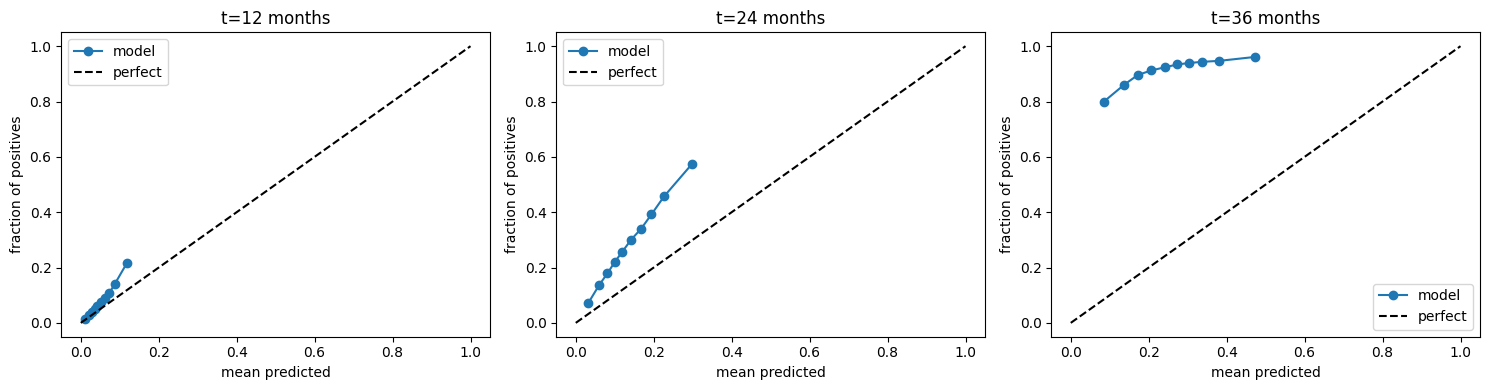

In [26]:
surv_test = predict_survival_at_horizons(test, horizons=[12, 24, 36])
T_test = test[DURATION_COL].values
E_test = test[EVENT_COL].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, t in zip(axes, [12, 24, 36]):
    mask     = ((T_test <= t) & (E_test == 1)) | (T_test > t)
    y_true_t = np.where(T_test[mask] <= t, 1, 0)
    y_pred_t = 1 - surv_test[t][mask]

    frac_pos, mean_pred = calibration_curve(y_true_t, y_pred_t, n_bins=10, strategy='quantile')

    ax.plot(mean_pred, frac_pos, marker='o', label='model')
    ax.plot([0, 1], [0, 1], 'k--', label='perfect')
    ax.set_title(f't={t} months')
    ax.set_xlabel('mean predicted')
    ax.set_ylabel('fraction of positives')
    ax.legend()

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/calibration_deepsurv.png', dpi=120)
plt.show()

# 16. Sample Survival Curves

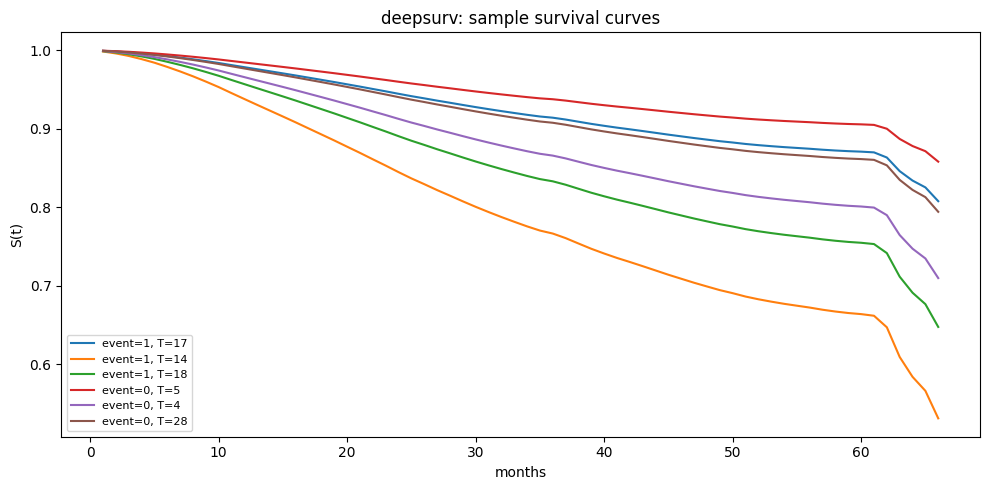

In [27]:
np.random.seed(RANDOM_STATE)
defaulted = test[test[EVENT_COL] == 1].sample(3)
censored  = test[test[EVENT_COL] == 0].sample(3)
samples   = pd.concat([defaulted, censored])

sample_surv = predict_survival_matrix(samples, times=event_times_sorted)

fig, ax = plt.subplots(figsize=(10, 5))

for i, (_, row) in enumerate(samples.iterrows()):
    label = f"event={int(row[EVENT_COL])}, T={int(row[DURATION_COL])}"
    ax.plot(event_times_sorted, sample_surv[i], label=label)

ax.set_xlabel('months')
ax.set_ylabel('S(t)')
ax.set_title('deepsurv: sample survival curves')
ax.legend(fontsize=8)
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/survival_curves_deepsurv.png', dpi=120)
plt.show()